## Linear Regression implementation in scikit-learn 

In [2]:
from sklearn.datasets import make_regression
from sklearn.linear_model import LinearRegression

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

import numpy as np
import seaborn as sns

import pandas as pd

import matplotlib as mpl
plt.style.use("ggplot")
plt.rcParams["figure.dpi"] = 100
font = {"family": "sans-serif", "size": 12}

mpl.rc("font", **font)

from IPython.display import Image

In [3]:
# Synthetic dataset 
# fix the seed 
np.random.seed(7)
X, y = make_regression(n_samples=300, n_features=1, noise=20, random_state=7) # for single feature
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)
print(X_train.shape, X_test.shape, X_test.shape[0]/X_train.shape[0])


(240, 1) (60, 1) 0.25


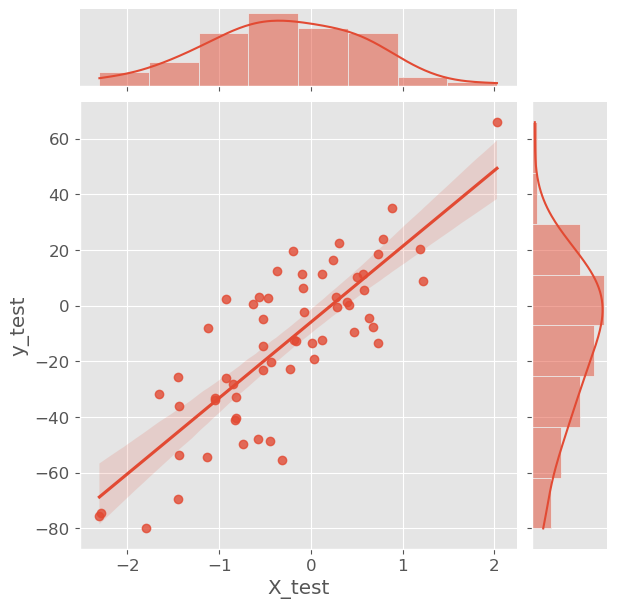

In [4]:
sns_test = sns.jointplot(x = X_test.ravel(), y=y_test.ravel(), kind='reg')

sns_test.set_axis_labels("X_test", "y_test")


In [5]:
from sklearn.metrics import mean_squared_error, r2_score

lr = LinearRegression().fit(X_train, y_train) # instance of Linear Regression
y_pred = lr.predict(X_test)
# Print co efficients 
slope = lr.coef_
intercept = lr.intercept_

print(f"Slope: {slope}, \n Intercept: {intercept}")

# Train and test score
print(f"Training set score: {lr.score(X_train, y_train):.2f}")
print(f"Test set score: {lr.score(X_test, y_test):.2f}")

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred)}")
print(r"$R^2$" f"= {r2_score(y_test, y_pred)}")


Slope: [29.49488324], 
 Intercept: -1.1604923340894446
Training set score: 0.68
Test set score: 0.63
Mean Squared Error: 306.78530909578495
$R^2$= 0.6341552930964304


# Linear Regression from scratch

Linear regression model consists of one equation of linearly increasing variables along with a coefficient estimation algorithm 'least squares', which attempts to determine the best possible coefficients. Commonly used in forecasting, trend analysis, and predictive modelling.

The equation of a simple linear regression model is:

$$\hat{y}​=b_0 ​+ b_1 ​x $$

We can calculate the slope ($b_1$) and intercept ($b_0$) using the least-squares equations:


$$ b_1 = \frac{cov(x,y)} {var(x)} = \frac{\sum (x_i-\bar{x})(y_i-\bar{y})} {\sum (x_i-\bar{x})^2} $$


$$ b_0 = \bar{y} -\frac{cov(x,y)} {var(x)}\bar{x} = \bar{y} - b_1 \bar{x}$$

Mean-squared error ([Scikit documentation](https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error))

If $y_i$: Actual value, $\hat{y}_i$: Predicted value, $\bar{y}$ = mean of actual values

$$
\text{MSE}(y, \hat{y}) = \frac{1}{n_\text{samples}} \sum_{i=0}^{n_\text{samples} - 1} (y_i - \hat{y}_i)^2.
$$

$R^2$ score (**coefficient of determination**)

$$
R^2 = 1 - \frac{\text{SS}_{\text{res}}}{\text{SS}_{\text{tot}}}
$$

Where:

Residual Sum of Squares

$$
  \text{SS}_{\text{res}} = \sum_{i=1}^{n} \left( y_i - \hat{y}_i \right)^2
$$



Total Sum of Squares

$$
  \text{SS}_{\text{tot}} = \sum_{i=1}^{n} \left( y_i - \bar{y} \right)^2
$$  

- $R^2 = 1$ -> perfect predictions
- $R^2 = 0$ -> no better than predicting the mean
- $R^2 < 0$ -> worse than predicting the mean


In [6]:
class MyLinearRegression():
    def __init__(self):
        self.coeff = None
    
    def fit(self, X, y):
        self.coeff = self.calculate_b0_b1(X,y)
                
    def  calculate_b0_b1(self, X, y):
        x_mean = np.mean(X)
        y_mean = np.mean(y)

        # Calculate slope
        numerator = np.sum((X - x_mean) * (y - y_mean))
        denominator = np.sum((X - x_mean) ** 2)

        b1 = numerator / denominator

        # Calculate intercept
        b0 = y_mean - b1 * x_mean   
        
        return [b0, b1]
    
    def predict(self, X):
        
        y_pred = self.coeff[0] + self.coeff[1]*X
        return y_pred
        
    def MSE(self, y_test, y_pred):
        return (np.mean((y_pred - y_test)**2))
    
    def r2_score(self,y_test, y_pred):
        ss_res = np.sum((y_test - y_pred) ** 2)

        ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

        r2 = 1 - (ss_res / ss_tot)    
        return r2
        

In [7]:
# # # # # # # # # # # # # # # # #
# My Linear Regression #
# # # # # # # # # # # # # # # # #
my_lr = MyLinearRegression()

# Update the shape properly to 1D array
X_train = X_train.ravel()
X_test  = X_test.ravel()

y_train = y_train.ravel()
y_test  = y_test.ravel()

# fit our LR to our data
my_lr.fit(X_train, y_train)
#coeffs
coeff = my_lr.calculate_b0_b1(X_train, y_train)
print(f"Slope: {coeff[1]}, \n Intercept: {coeff[0]}")
# make predictions and score
y_pred = my_lr.predict(X_test)

# calculate r2_score
r2score = my_lr.r2_score(y_test, y_pred)
print(f'My Final R2 score: {r2score}')

# calculate MSE 
mse = my_lr.MSE(y_test, y_pred)
print(f'My Final MSE score: {mse}')



Slope: 29.49488323993304, 
 Intercept: -1.1604923340894446
My Final R2 score: 0.6341552930964304
My Final MSE score: 306.78530909578495


## Diabetic dataset :: Example of Multiple Linear Regression

In [8]:

from sklearn import datasets
diabetes = datasets.load_diabetes()
diabetes.keys()
print(diabetes["DESCR"])

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [9]:
df = pd.DataFrame(
    diabetes.data,
    columns=diabetes.feature_names
)

df["target"] = diabetes.target

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


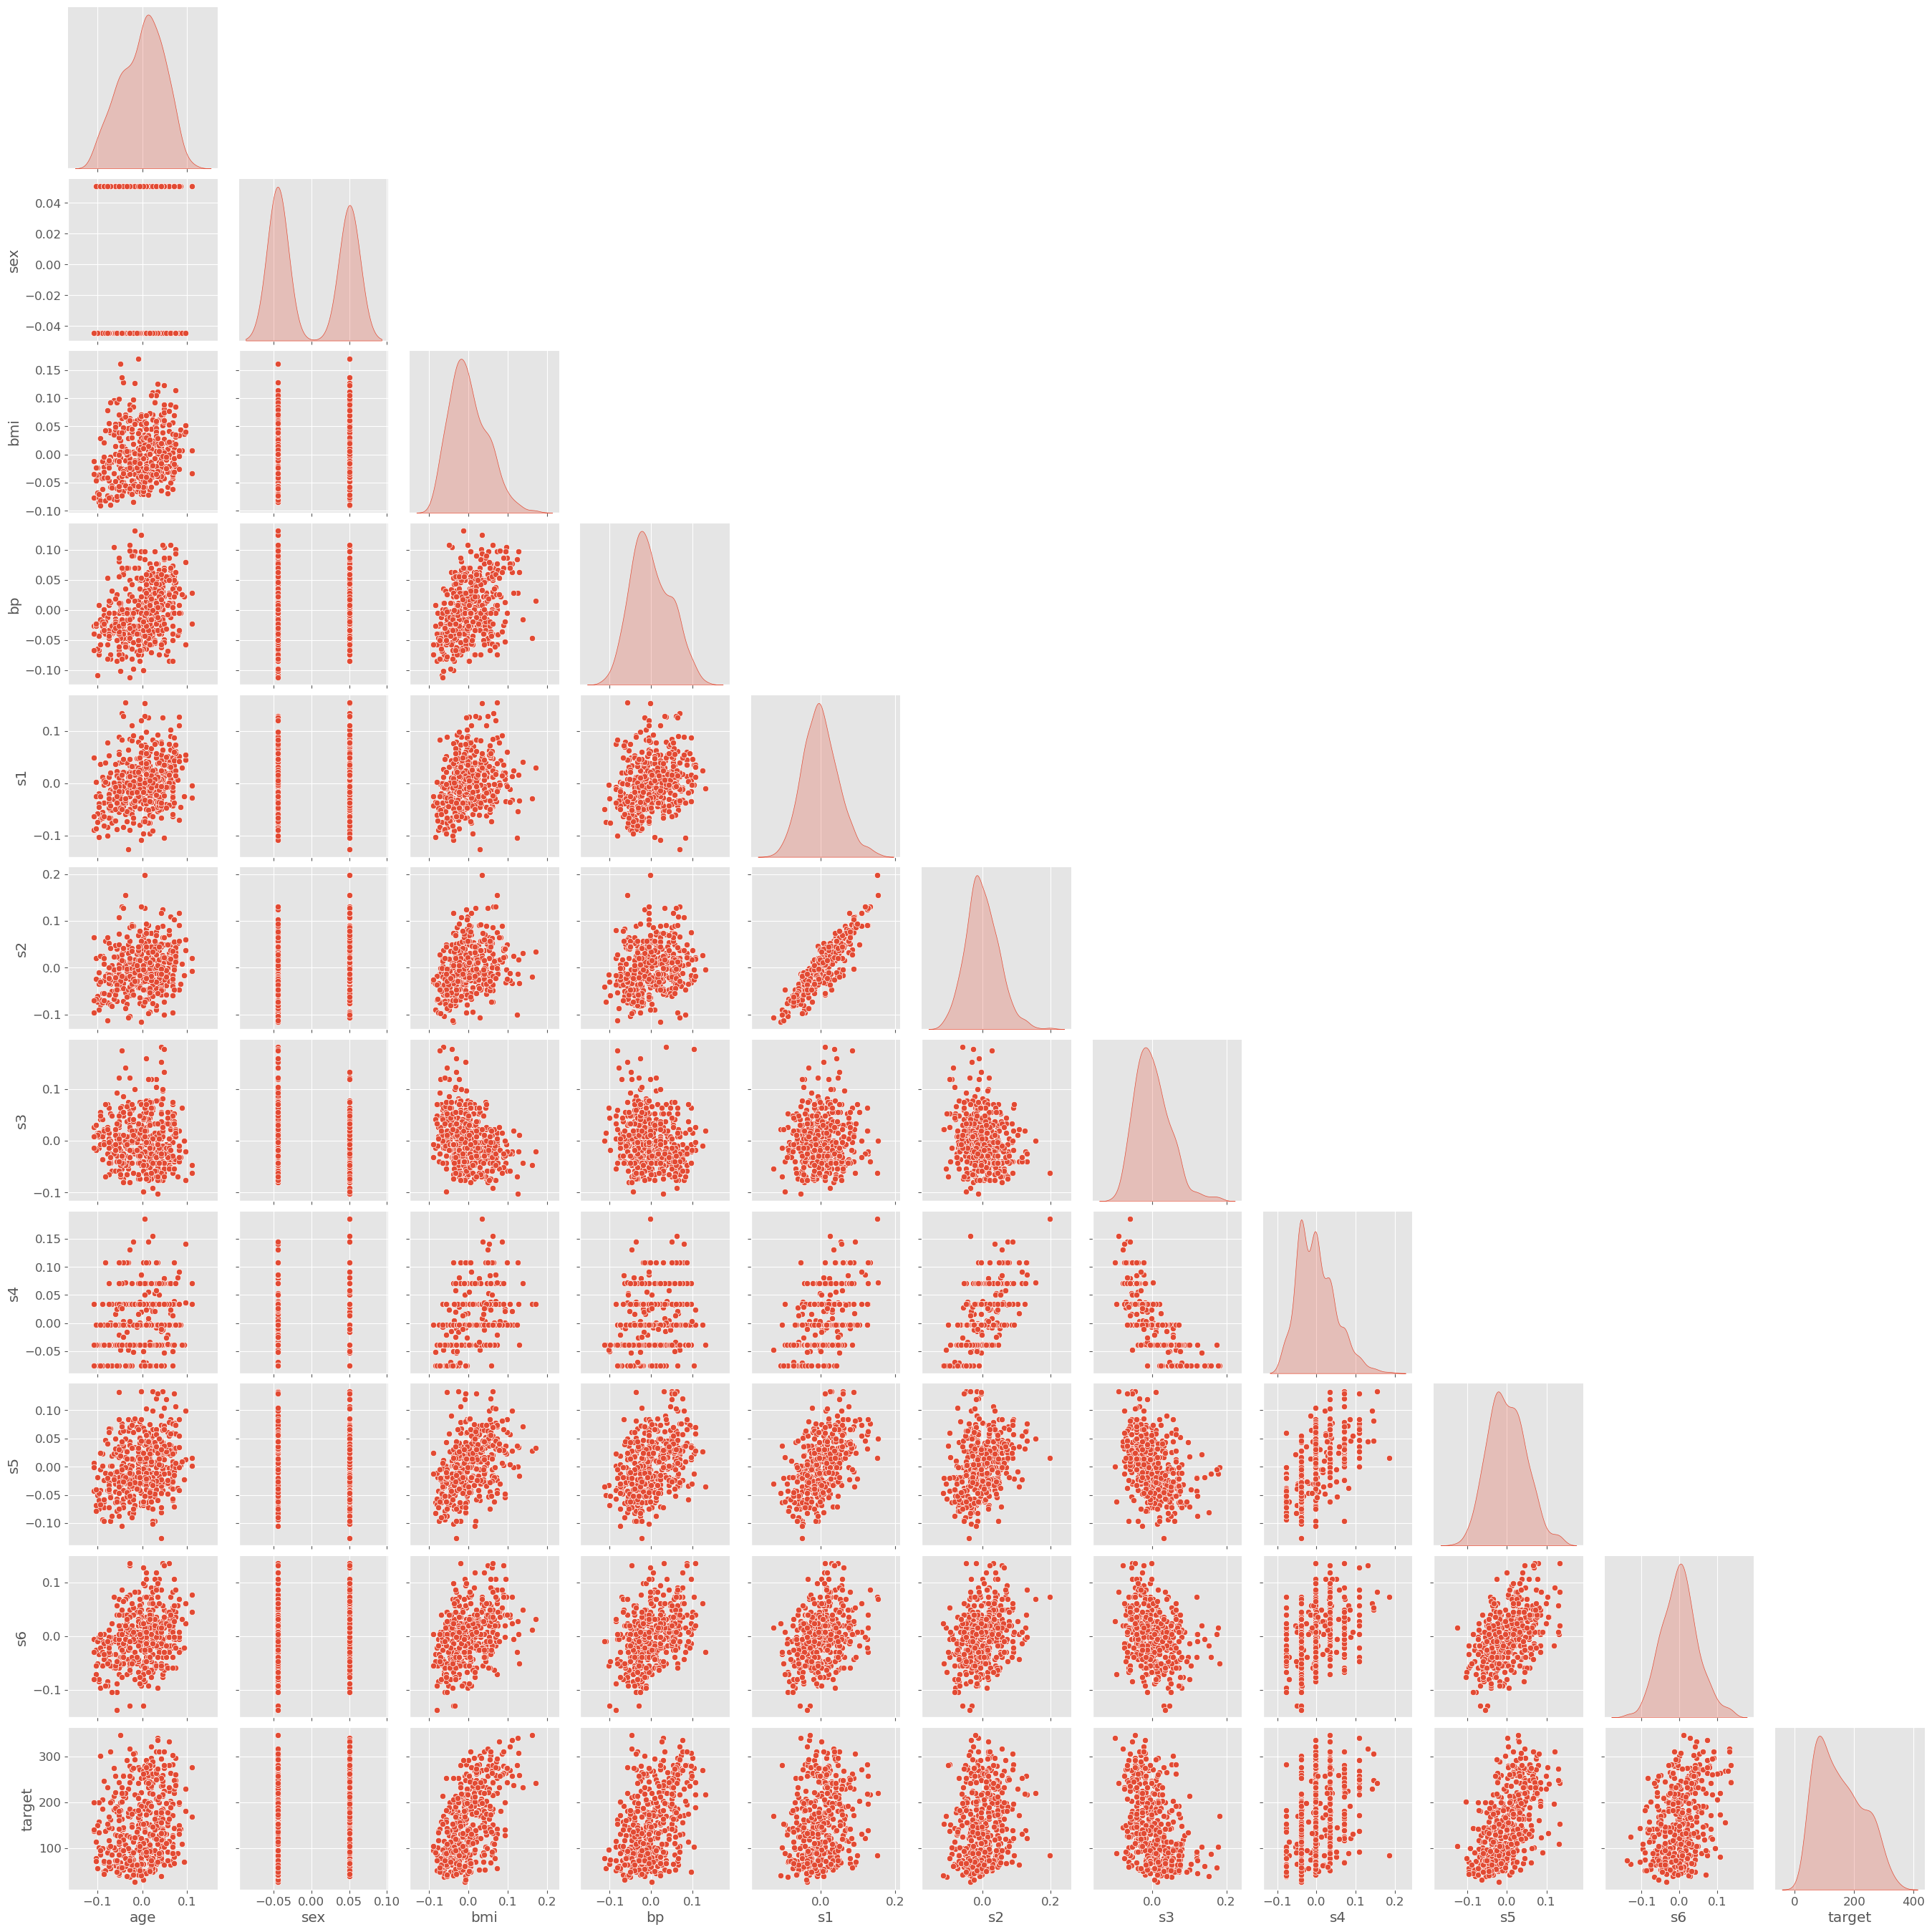

In [10]:
sns.pairplot(df,corner=True,diag_kind='kde')

In [11]:
df.keys()
print(f'check the preprocessing if the sum of squares are 1 for each column:  {np.sum(df.age**2)}')

check the preprocessing if the sum of squares are 1 for each column:  1.0000000000000009


In [12]:
df['target']

0      151.0
1       75.0
2      141.0
3      206.0
4      135.0
       ...  
437    178.0
438    104.0
439    132.0
440    220.0
441     57.0
Name: target, Length: 442, dtype: float64

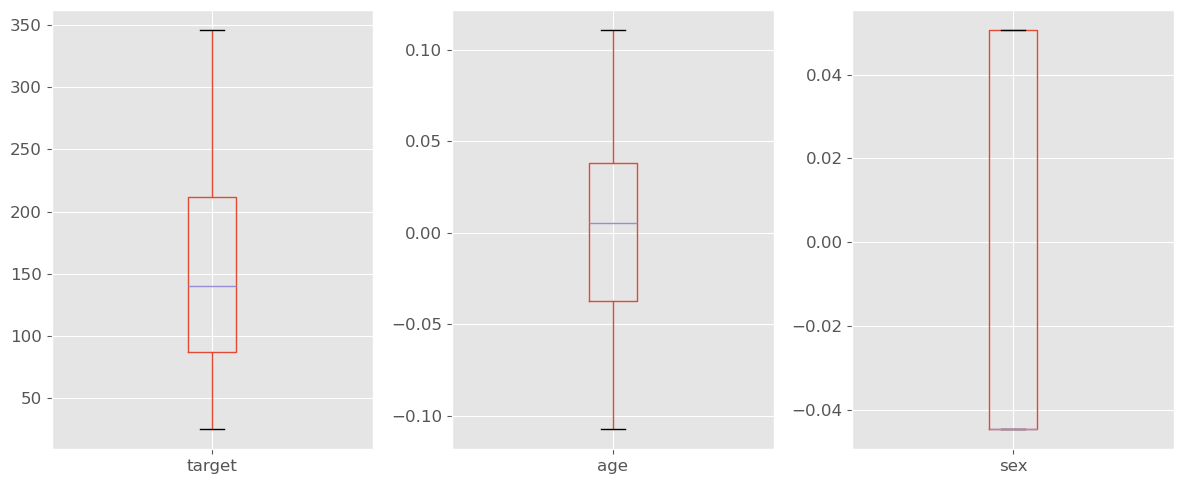

In [ ]:
# Are there outliers in the data?
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

df.boxplot(column='target', ax=axes[0])
df.boxplot(column='age', ax=axes[1])
df.boxplot(column='sex', ax=axes[2])

plt.tight_layout()
plt.show()

In [14]:
print("Missing values:")
print(df.isnull().sum())

print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

Missing values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Number of duplicate rows:
0


In [15]:
df.keys()

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6',
       'target'],
      dtype='object')

In [16]:
y = df['target']
X = df.drop('target', axis= 1) # axis = 1 for column axis 

In [17]:
X_train, X_test, y_train, y_test = train_test_split(X,y,random_state=0)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (331, 10)
X_test : (111, 10)
y_train: (331,)
y_test : (111,)


In [18]:
lr = LinearRegression().fit(X_train, y_train)

y_pred = lr.predict(X_test)

print(f"Coefficients = {lr.coef_}")
print(f"Intercept = {lr.intercept_}")

print(f"Training set r2 score = {lr.score(X_train, y_train):.2f}")
print(f"Test set r2 score = {lr.score(X_test, y_test):.2f}")

print(f"Mean Squared Error: {mean_squared_error(y_test, y_pred):.2f}")
pass

Coefficients = [ -43.26198867 -208.66589855  593.40654802  302.89100542 -560.19094014
  261.40753499   -8.86674758  135.93174293  703.18354112   28.34977176]
Intercept = 153.06786205925664
Training set r2 score = 0.56
Test set r2 score = 0.36
Mean Squared Error: 3180.16


# Multiple Linear Regression from scratch

Multiple linear regression is a model that captures the linear relationship between a dependent variable and multiple independent variables or features. Simple regression works when only one factor explains the outcome.
But in practice, outcomes are influenced by many variables.

- With 1 input → regression gives a line.
- With 2 inputs → regression gives a plane in 3D space.
- With n inputs → regression gives a hyperplane in n-dimensional space.


The general multiple linear regression model is:

$$
y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \cdots + \beta_i x_i + \epsilon
$$

where:

- $\beta_0$ is the intercept.
- $\beta_0$ to $\beta_i$ are the regression coefficients.
- $x_1$ to $x_i$ are the features of the dataset.
- $\epsilon$ represents the residual or error term.

## Vector Representation

The multiple linear regression equation can also be represented using vector and matrix notation:

$$
\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\epsilon}
$$

where:

$$
\mathbf{y}
=
\begin{bmatrix}
y_1 \\
y_2 \\
\vdots \\
y_n
\end{bmatrix},
\qquad
\mathbf{X}
=
\begin{bmatrix}
\mathbf{x}_0^{\mathsf{T}} \\
\mathbf{x}_1^{\mathsf{T}} \\
\vdots \\
\mathbf{x}_n^{\mathsf{T}}
\end{bmatrix},
$$

$$
\boldsymbol{\beta}
=
\begin{bmatrix}
\beta_0 \\
\beta_1 \\
\beta_2 \\
\vdots \\
\beta_i
\end{bmatrix},
\qquad
\boldsymbol{\epsilon}
=
\begin{bmatrix}
\epsilon_1 \\
\epsilon_2 \\
\vdots \\
\epsilon_n
\end{bmatrix}.
$$

The vector $\mathbf{x}_0^{\mathsf{T}}$ contains a series of ones:

$$
\mathbf{x}_0^{\mathsf{T}} =
\begin{bmatrix}
1 & 1 & \cdots & 1
\end{bmatrix}.
$$

This column of ones allows the intercept term $\beta_0$ to be included in the matrix equation.

Using an estimate of the coefficient vector $\boldsymbol{\beta}$, the predicted output can be calculated as:

$$
\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol{\beta}}.
$$


The $\beta$ values are estimated by minimizing the *Sum of Squred Residuals* (SSR):
$$
SSR(\beta) = \sum_{i}^{n}(y_i - \hat{y})^2 = \sum_{i}^{n}(y_i - \mathbf{X}\hat{\boldsymbol{\beta}})^2
$$


Cost Function: 
$$
J = \mathcal{L} (y_i, \hat{y}_i) \equiv SSR =  (Y - X\beta)^{T} (Y - X\beta)
$$

minimyzing the cost fucntion by partial differentiation w.r.t $\beta$ gives
$$
\beta = (X^T X)^{-1} X^T y  
$$

In [19]:
class MultipleLinearRegression():
        def __init__(self):
                self.coefficients = None
                self.intercept = None
        
        def fit(self, X, y):
                betas = self.calculate_coeff(X,y)
                self.intercept = betas[0]
                self.coefficients = betas[1:]
                
        def predict(self, X):
                y_pred = self.intercept + X @ self.coefficients
                return y_pred     
        
        def calculate_coeff(self, X, y):
                X = X.to_numpy()
                y = y.to_numpy()
                
                # add an identity column at the first in the X matrix 
                X = np.insert(X, 0, 1, axis=1)  
                
                betas = np.linalg.inv(X.T @ X) @ X.T @ y

                return betas  
        
        def r2_score(self, y_test, y_pred):
                ss_res = np.sum((y_test - y_pred) ** 2)
                ss_tot = np.sum((y_test - np.mean(y_test)) ** 2)

                r2 = 1 - (ss_res / ss_tot)

                return r2    
        
        def MSE(self, y_test, y_pred):
                return (np.mean((y_pred - y_test)**2))

In [20]:
X_test.columns

Index(['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'], dtype='object')

In [21]:
mlr = MultipleLinearRegression()

mlr.fit(X_train, y_train)

# fit our LR to our data
mlr.fit(X_train, y_train)

#coeffs
coeff = mlr.calculate_coeff(X_train, y_train)
print(f"Slope: {coeff[1:]}, \n Intercept: {coeff[0]}")
# make predictions and score
y_pred = mlr.predict(X_test)

# calculate r2_score
r2score = mlr.r2_score(y_test, y_pred)
print(f'My Final R2 score: {r2score}')

# calculate MSE 
mse = mlr.MSE(y_test, y_pred)
print(f'My Final MSE score: {mse}')


Slope: [ -43.26198867 -208.66589855  593.40654802  302.89100542 -560.19094014
  261.40753499   -8.86674758  135.93174293  703.18354112   28.34977176], 
 Intercept: 153.06786205925664
My Final R2 score: 0.35940880381777085
My Final MSE score: 3180.1596481558445


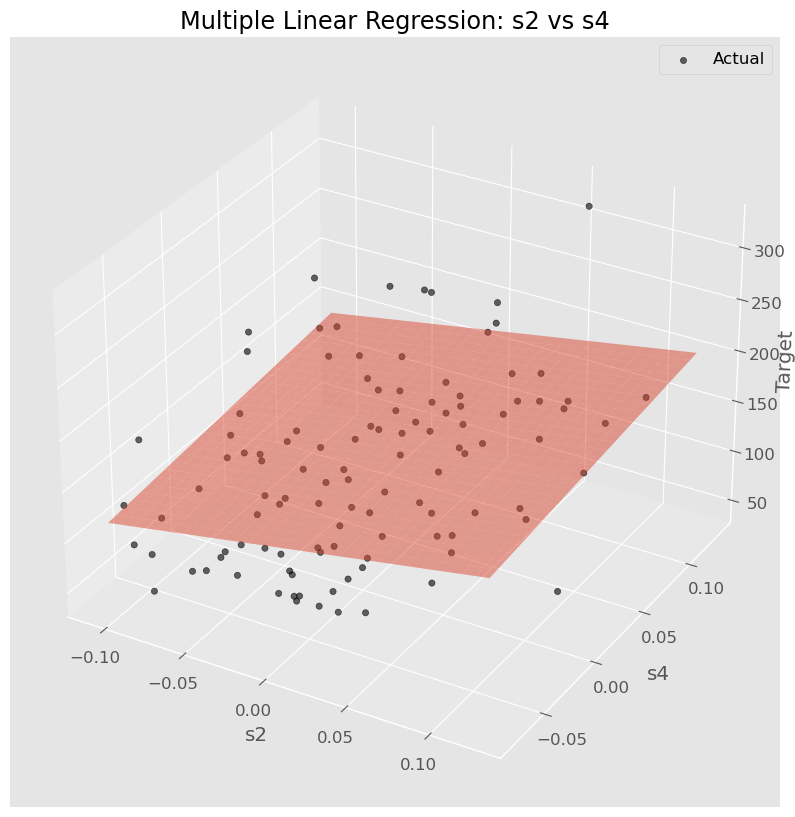

In [ ]:
# 3D Visualization

from mpl_toolkits.mplot3d import Axes3D

# --------------------------------------------------
# Select two features for visualization
# --------------------------------------------------

feature1 = 's2'
feature2 = 's4'

# Actual test data
x = X_test[feature1]
y = X_test[feature2]
z = y_test


# --------------------------------------------------
# Create grid for the regression surface
# --------------------------------------------------

x_pred = np.linspace(x.min(), x.max(), 30)
y_pred = np.linspace(y.min(), y.max(), 30)

X1, X2 = np.meshgrid(x_pred, y_pred)


# --------------------------------------------------
# Calculate predicted target using full model
# --------------------------------------------------

# Coefficients
b0   = coeff[0]    # intercept
b_s4 = coeff[8]   # s4
b_s2  = coeff[6]   # s2

# Start with intercept + s2 + age
Z_pred = b0 + b_s2 * X1 + b_s4 * X2


# # --------------------------------------------------
# # Add contribution from remaining 8 features
# # --------------------------------------------------

# for i, feature in enumerate(X.columns):

#     if feature not in [feature1, feature2]:

#         # coefficient index = feature index + 1
#         beta = coeff[i + 1]

#         # Fix remaining feature at its training mean
#         Z_pred += beta * X_train[feature].mean()


# --------------------------------------------------
# 3D plot
# --------------------------------------------------

fig = plt.figure(figsize=(20, 10))

ax = fig.add_subplot(111, projection='3d')


# Actual test data
ax.scatter(x, y, z,color='black',alpha=0.6,label='Actual')


# Regression surface
ax.plot_surface(X1, X2, Z_pred,alpha=0.5)


# Labels
ax.set_xlabel('s2')
ax.set_ylabel('s4')
ax.set_zlabel('Target', labelpad=0.3)
ax.set_title('Multiple Linear Regression: s2 vs s4')
ax.legend()
plt.show()

## Ridge Regression (L2 regularization)

Linear regression with an **L2 regularization** term to prevent overfitting by penalizing large coefficients. It's useful when there are **many correlated features** in the dataset.

$$
\min_w \sum_{i=1}^{n} (y_i - X_i w)^2 + \alpha \sum_{j=1}^{D} w_j^2
$$

$\alpha$ is the regularization parameter (controls the strength of penalty). A higher $\alpha$ shrinks the coefficients towards zero, reducing model complexity. It **does not eliminate features**, though.

- L2 Regularization: Adds an L2 penalty to model weights
- Bias-Variance Tradeoff: Controls how large coefficients can grow
- Multicollinearity: Improves stability when features overlap
- Generalization: Helps the model generalize better on new data


$\alpha$ is a hyperparameter that controls the degree of fit of the model and may be related to the model bias-variance trade-off. 


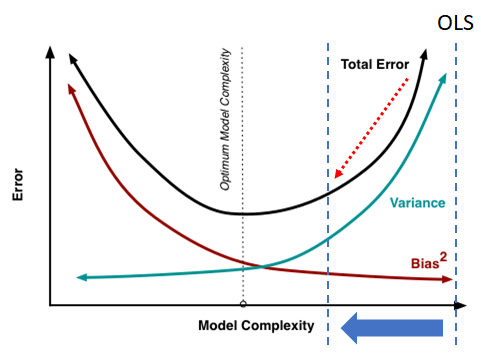


- for $ \alpha \to 0 $ the solution approaches linear regression, there is no bias (relative to a linear model fit), but the model variance is likely higher

- as $\alpha$ increases the model variance decreases and the model bias increases, the model becomes simpler

- for $\alpha \to \inf$ the model parameters $w_1,...w_D$ shrink to 0.0 and the model predictions approaches the training data response feature mean


Analytical solution, starting with the loss function with, least squares (left) and regularization (right) terms:

$$
(RSS + shrinkage)  =  \sum_{i}^{n}(y_i - \hat{y})^2  + \alpha \sum_{j=1}^{D} w_j^2 = \sum_{i}^{n}(y_i - \mathbf{X}\hat{\boldsymbol{\beta}})^2 +  + \alpha \sum_{j=1}^{D} w_j^2 \\

= (Y - X\beta)^T (Y - X\beta) + \alpha \beta^T \beta
$$

Minimization becomes:

$$
\beta = (X^T X + \alpha I)^{-1} X^T y
$$



for [detailed calculation](https://geostatsguy.github.io/MachineLearningDemos_Book/MachineLearning_ridge_regression.html)

alpha=0, training score=0.56, test score = 0.36, Test MSE = 3180.16
alpha=1e-06, training score=0.56, test score = 0.36, Test MSE = 3180.16
alpha=0.001, training score=0.56, test score = 0.36, Test MSE = 3183.96
alpha=0.01, training score=0.55, test score = 0.36, Test MSE = 3193.77
alpha=0.1, training score=0.55, test score = 0.37, Test MSE = 3132.42
alpha=1, training score=0.46, test score = 0.36, Test MSE = 3192.32
alpha=10, training score=0.17, test score = 0.14, Test MSE = 4252.86
alpha=100, training score=0.02, test score = 0.02, Test MSE = 4865.76
alpha=1000, training score=0.00, test score = 0.00, Test MSE = 4954.79


Text(0.5, 0, '$\\alpha$')

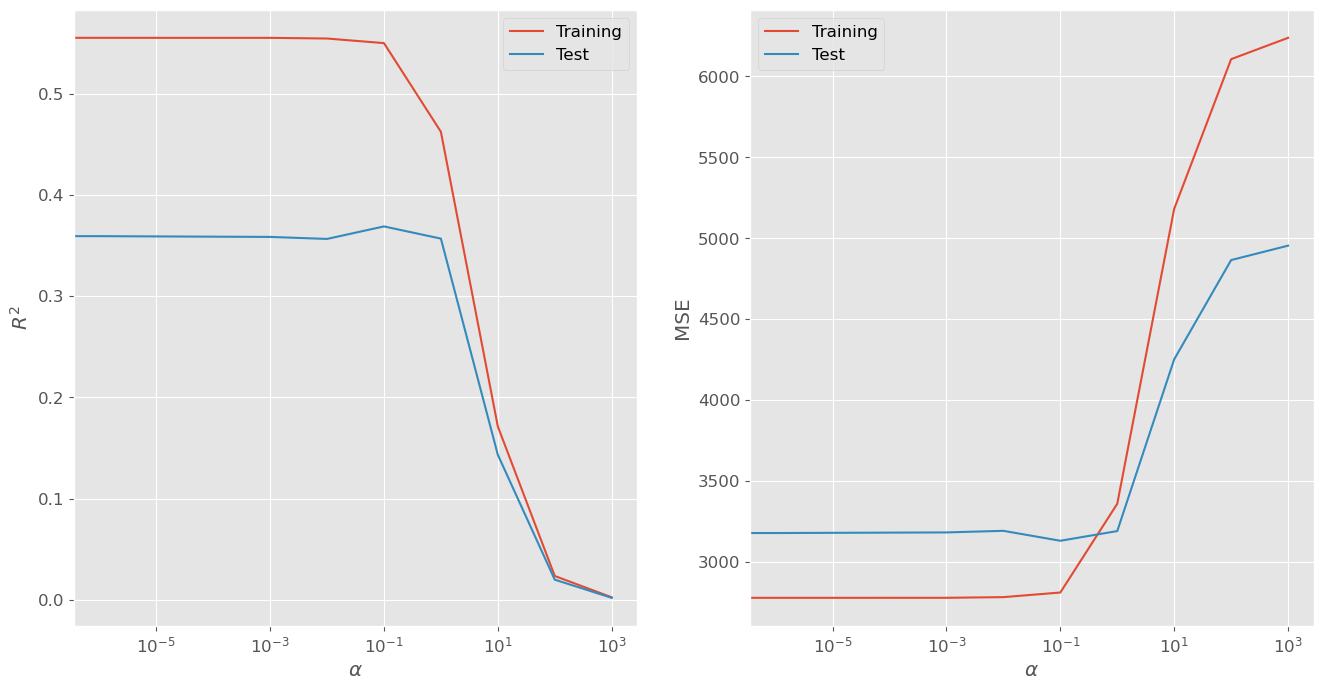

In [ ]:
from sklearn.linear_model import Ridge

alpha_values = [0, 1e-6, 0.001, 0.01, 0.1, 1, 10, 100, 1000]

training_score = []
test_score = []
training_mse = []
test_mse = []


for val in alpha_values:
    ridge = Ridge(alpha=val).fit(X_train, y_train)
    y_pred = ridge.predict(X_test)
    
    train_score = ridge.score(X_train, y_train)
    tst_score = ridge.score(X_test, y_test)
    training_score.append(train_score)
    test_score.append(tst_score)
    
    y_train_pred = ridge.predict(X_train)
    trn_mse = mean_squared_error(y_train, y_train_pred)
    training_mse.append(trn_mse)
    tst_mse = mean_squared_error(y_test, y_pred)
    test_mse.append(tst_mse)

    print(
        f"alpha={val}, training score={train_score:.2f}, test score = {tst_score:.2f}, Test MSE = {tst_mse:.2f}"
    )

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

plt.sca(axes[0])
plt.plot(alpha_values, training_score, label="Training")
plt.plot(alpha_values, test_score, label="Test")
plt.xscale('log')
plt.legend()
plt.ylabel("$R^2$")
plt.xlabel(r"$\alpha$")


plt.sca(axes[1])
plt.plot(alpha_values, training_mse, label="Training")
plt.plot(alpha_values, test_mse, label="Test")
plt.xscale('log')
plt.legend()
plt.ylabel("MSE")
plt.xlabel(r"$\alpha$")
    

Inferences about model complexity and bias variance trade off: 

- Increasing alpha which also indicates lower model complexity, causes both training and test R^2 to decrease. With large $\alpha$, the Ridge coeff i.e the w becomes small. 

- Small R^2 ($\to 0$) means the model `underfits` the data and hence the bias is high.  

- What about variance! i.e. Variance suggests how much the model is sensitive to the train data ; usually thought of as the difference in train and test error. With high bias the variance should be low;
 This is evident in R^2 but not particularly realised in MSE.Always train–test error gap does not mean model variance is increasing, probably checking with different training set might help.  


<p align="center">
<img src="images/remember.png" width="400" height="200">
</p>


## Lasso Regression